# 15.2 Representation of materials

### Packages used Pandas, RDKit, Numpy, Matplotlib, Scipy, Torch, Pymatgen, Torch_geometric 

# 15.2.1 The representation of organic molecules
**Y6 as an example**

## 15.2.1 (1) Descriptor representation

In [26]:
import pandas as pd 
from rdkit import Chem
from rdkit.Chem import Descriptors

def rdkit_descriptors(mol):
        """
        Get the molecular descriptors by iterating over all possible descriptors.
        Parameters
        ----------
        mol : object
            An rdkit molecules object.

        Returns
        -------
        dict
            Dictionary that contains the molecular descriptor names as keys and their respective values 
        """
        ret_dict = {}

        # Iterate over all descriptors, get their functions (func) and apply to the molecule object
        for name,func in Descriptors.descList:
                ret_dict[name] = func(mol)
        return(ret_dict)

def getf(mol,progs=["rdkit"]):
        """
        Main function that makes the call to rdkit or cdk

        Parameters
        ----------
        mol : object
        An rdkit molecules object.
        progs : list
            List containing the tools to use for calculating molecular descriptors. Use "rdkit"

        Returns
        -------
        dict
                Dictionary that contains the molecular descriptor names as keys and their respective values 
        """
        ret_dict = {}
        if "rdkit" in progs: ret_dict["rdkit"] = rdkit_descriptors(mol)
        return(ret_dict)

In [27]:
#Input SMILES of materials
smi = 'CCCCCCCCCCCC1=C(/C=C2\C(=O)C3=C(C=C(F)C(F)=C3)C2=C(C#N)C#N)SC2=C1SC1=C2N(CC(CC)CCCC)C2=C1C1=NSN=C1C1=C2N(CC(CC)CCCC)C2=C1SC1=C2SC(/C=C2\C(=O)C3=C(C=C(F)C(F)=C3)C2=C(C#N)C#N)=C1CCCCCCCCCCC'
mol = Chem.MolFromSmiles(smi)
a = getf(mol)
print (a['rdkit'])

{'MaxAbsEStateIndex': 15.230530575756806, 'MaxEStateIndex': 15.230530575756806, 'MinAbsEStateIndex': 0.005030299821335182, 'MinEStateIndex': -1.1895377056179937, 'qed': 0.016636918813198495, 'SPS': 14.554455445544555, 'MolWt': 1451.9709999999989, 'HeavyAtomMolWt': 1365.2829999999985, 'ExactMolWt': 1450.541341872, 'NumValenceElectrons': 524, 'NumRadicalElectrons': 0, 'MaxPartialCharge': 0.19400470456652127, 'MinPartialCharge': -0.3365155529568668, 'MaxAbsPartialCharge': 0.3365155529568668, 'MinAbsPartialCharge': 0.19400470456652127, 'FpDensityMorgan1': 0.43564356435643564, 'FpDensityMorgan2': 0.7722772277227723, 'FpDensityMorgan3': 1.108910891089109, 'BCUT2D_MWHI': 32.1422313299554, 'BCUT2D_MWLOW': 9.977166219913244, 'BCUT2D_CHGHI': 2.385546277088211, 'BCUT2D_CHGLO': -2.2003818250184133, 'BCUT2D_LOGPHI': 2.563903547439934, 'BCUT2D_LOGPLOW': -2.1251289559871793, 'BCUT2D_MRHI': 7.344825755159206, 'BCUT2D_MRLOW': 0.10311634462130666, 'AvgIpc': 1.5036465828154237, 'BalabanJ': 1.136092796511

## 15.2.1 (2) Fingerprint representation

In [28]:
from rdkit import Chem
from rdkit.Chem import RDKFingerprint
from rdkit.Chem import AllChem
from rdkit.Chem import MACCSkeys
from rdkit.Chem.AtomPairs import Pairs
from rdkit.Chem.AtomPairs import Torsions

mol = Chem.MolFromSmiles("CCCCCCCCCCCC1=C(/C=C2\C(=O)C3=C(C=C(F)C(F)=C3)C2=C(C#N)C#N)SC2=C1SC1=C2N(CC(CC)CCCC)C2=C1C1=NSN=C1C1=C2N(CC(CC)CCCC)C2=C1SC1=C2SC(/C=C2\C(=O)C3=C(C=C(F)C(F)=C3)C2=C(C#N)C#N)=C1CCCCCCCCCCC")
# RDKFingerprint
fp = RDKFingerprint(mol)
print('RDKFingerprint is' , fp.ToBitString())
# Morgan fingerprint
fp = AllChem.GetMorganFingerprint(mol, 2)
# convert to string format
fp_str = fp.ToBinary()
print('Morgan fingerprint is', fp_str)
fp1 = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024)
print('ECFPs fingerprint is', fp_str)
ffp1 = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=10, useFeatures=True)
print('FCFPs fingerprint is', fp_str)
# MACCS fingerprint
fp = MACCSkeys.GenMACCSKeys(mol)
# convert to string format
print('MACCS fingerprint is', fp.ToBitString())
# AtomPair fingerprint
fp = Pairs.GetAtomPairFingerprint(mol)
# Get non-zero elements
d = fp.GetNonzeroElements()
print('AtomPair fingerprint is', d)
# TopologicalTorsion fingerprint
fp = Torsions.GetTopologicalTorsionFingerprintAsIntVect(mol)
print('TopologicalTorsion fingerprint is',fp.ToBinary())


RDKFingerprint is 1111011111111111110111111111011111101111111111111110111111111111110111111001101111111111101110111111111110101110101111110111111111011111110111111111111111111111111111111111011011101111111111111111011111111101011111110101101011010111110111001110111111111011111111111011111111111111111101100101101111111011111111011111101111111011111100111111110010111110111111101110111111111111011001111111111111111101111111111111111111111101111111111101111101111111111110011111111110111011111111111111101111111111111111111100111111011111111110110111111110111111110111111111011100110111001111111111111111110111011111110111110111111101110110101111111111101111111111111111011111101111110011111111111111111110110110111011111111111111111011111111111111111100111111111111111110111111101111011110101001111111111111001111111110111011010111111101111110111111110101111111111111111111101111111111011111111111111101111111111111111111111111110011001111111111111011110101111111011110111101111111111101011011011101

## 15.2.1 (3) Molecular graph representation

In [29]:
from rdkit import Chem
import numpy as np

def smiles_to_graph(smiles):
    """
    Convert a SMILES string to the periodic boundaries and adjacency matrix of the molecular graph.

    Parameters:
        smiles (str): The SMILES string of the molecule.

    Returns:
        atoms (list): A list of atomic symbols.
        adjacency_matrix (numpy.ndarray): The adjacency matrix of the molecule.
    """
    # Convert the SMILES string to an RDKit molecule object
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("Failed to parse the SMILES string. Please check the input.")

    # Extract atomic symbols from the molecule
    atoms = [atom.GetSymbol() for atom in mol.GetAtoms()]

    # Get the adjacency matrix from the molecule
    adjacency_matrix = Chem.GetAdjacencyMatrix(mol)

    # Convert the adjacency matrix to a NumPy array for easier manipulation
    adjacency_matrix = np.array(adjacency_matrix, dtype=int)

    return atoms, adjacency_matrix

# Example usage
if __name__ == "__main__":
    # Convert the SMILES string of ethanol to atomic information and adjacency matrix
    smiles = "CCCCCCCCCCCC1=C(/C=C2\C(=O)C3=C(C=C(F)C(F)=C3)C2=C(C#N)C#N)SC2=C1SC1=C2N(CC(CC)CCCC)C2=C1C1=NSN=C1C1=C2N(CC(CC)CCCC)C2=C1SC1=C2SC(/C=C2\C(=O)C3=C(C=C(F)C(F)=C3)C2=C(C#N)C#N)=C1CCCCCCCCCCC"
    atoms, adjacency_matrix = smiles_to_graph(smiles)

    print("Atomic Information:", atoms)
    print("Adjacency Matrix:")
    print(adjacency_matrix)

Atomic Information: ['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'O', 'C', 'C', 'C', 'C', 'F', 'C', 'F', 'C', 'C', 'C', 'C', 'N', 'C', 'N', 'S', 'C', 'C', 'S', 'C', 'C', 'N', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'N', 'S', 'N', 'C', 'C', 'C', 'N', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'S', 'C', 'C', 'S', 'C', 'C', 'C', 'C', 'O', 'C', 'C', 'C', 'C', 'F', 'C', 'F', 'C', 'C', 'C', 'C', 'N', 'C', 'N', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C']
Adjacency Matrix:
[[0 1 0 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 1 0 1]
 [0 0 0 ... 0 1 0]]


# 15.2.2 The representation of inorganic materials
***SrTiO3 as example***

## 15.2.2 (1) Descriptor representation

Molecular Descriptors:
Atom 1: Voronoi Cell Volume = 2.0000, Neighbor Count = 4


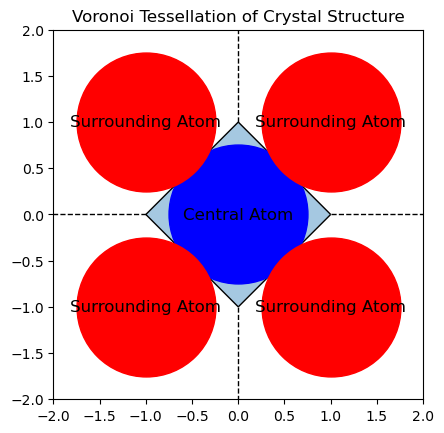

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d


def plot_voronoi_molecular_characterization(points):
    """
    Function to plot the Voronoi tessellation for a given set of points
    Parameters:
        points (str):  the positions of the atoms in the crystal structure

    Returns:
        molecular descriptors: Voronoi cell information.
       
    """
    # Generate the Voronoi tessellation
    vor = Voronoi(points)
    voronoi_cells = vor.regions
    voronoi_vertices = vor.vertices

    # Molecular descriptors
    volumes = []  # Placeholder for Voronoi cell volumes
    neighbors = []  # Placeholder for neighbor counts

    for i, point_index in enumerate(vor.point_region):
        region = vor.regions[point_index]
        if -1 not in region:  # Exclude infinite regions
            # Compute volume (area in 2D)
            polygon = vor.vertices[region]
            volume = 0.5 * np.abs(np.dot(polygon[:, 0], np.roll(polygon[:, 1], 1)) -
                              np.dot(polygon[:, 1], np.roll(polygon[:, 0], 1)))
            volumes.append(volume)
            neighbors.append(len(region))  # Number of vertices corresponds to neighbor count

    # Print molecular descriptors
    print("Molecular Descriptors:")
    for i, (volume, neighbor_count) in enumerate(zip(volumes, neighbors)):
        print(f"Atom {i + 1}: Voronoi Cell Volume = {volume:.4f}, Neighbor Count = {neighbor_count}")
    # Plot the Voronoi diagram
    fig, ax = plt.subplots()
    voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='black', line_width=1, point_size=100)
    
    # Add color to the regions for better visualization
    for region in vor.regions:
        if not -1 in region and len(region) > 0:
            polygon = [vor.vertices[i] for i in region]
            ax.fill(*zip(*polygon), alpha=0.4)

    # Plot the atoms
    for i, point in enumerate(points):
        ax.plot(point[0], point[1], 'o', color='red' if i > 0 else 'blue', markersize=100)
        if i == 0:
            ax.text(point[0], point[1], 'Central Atom', fontsize=12, ha='center', va='center')
        else:
            ax.text(point[0], point[1], 'Surrounding Atom', fontsize=12, ha='center', va='center')
    
    # Set the limits of the plot
    ax.set_xlim(min(points[:,0])-1, max(points[:,0])+1)
    ax.set_ylim(min(points[:,1])-1, max(points[:,1])+1)
    ax.set_aspect('equal')
    plt.title("Voronoi Tessellation of Crystal Structure")
    plt.show()

# Example usage
if __name__ == "__main__":
    # Define the positions of the atoms in the crystal structure
    # Central atom at the origin and surrounding atoms at the corners of a square
    central_atom_position = np.array([0.0, 0.0])
    surrounding_atom_positions = np.array([
        [1.0, 1.0],
        [-1.0, 1.0],
        [-1.0, -1.0],
        [1.0, -1.0]
    ])

    # Combine the positions into one array
    all_atom_positions = np.vstack((central_atom_position, surrounding_atom_positions))

    # Call the function to plot the Voronoi tessellation
    plot_voronoi_molecular_characterization(all_atom_positions)

## 15.2.2 (2) crystal graph representation

In [31]:
import numpy as np
from pymatgen.core import Structure
from scipy.spatial import cKDTree
import torch
from torch_geometric.data import Data

class CrystalGraph:
    """
    Convert a pymatgen Structure to a graph representation
    Parameters:
        structure:  cubic perovskite structure

    Returns:
        molecular descriptors: Voronoi cell information.
       
    """
    def __init__(self, cutoff=5.0):
        self.cutoff = cutoff  # Atomic distance cutoff radius (Å)
        self.atomic_features = {  # Atomic feature dictionary
            'Sr': [38, 2.45, 0.95],  # [Atomic number, Electronegativity, Atomic radius (Å)]
            'Ti': [22, 1.54, 1.47],
            'O':  [8,  3.44, 0.66]
        }
    
    def build_graph(self, structure):
        
        # Handle periodic boundaries
        expanded_structure = self._expand_supercell(structure)
        
        # Build atomic feature matrix
        node_features = self._get_node_features(expanded_structure)
        
        # Extract edge connections and edge attributes
        edge_index, edge_attr = self._get_edges(expanded_structure)
        
        return Data(
            x=torch.tensor(node_features, dtype=torch.float),
            edge_index=torch.tensor(edge_index, dtype=torch.long),
            edge_attr=torch.tensor(edge_attr, dtype=torch.float)
        )

    def _expand_supercell(self, structure):
        """Expand to 3×3×3 supercell for periodic boundary handling"""
        return structure * (3, 3, 3)
    
    def _get_node_features(self, structure):
        """Extract atomic features"""
        return np.array([self.atomic_features[str(site.specie)] 
                       for site in structure])
    
    def _get_edges(self, structure):
        """Find neighboring atoms using KDTree"""
        coords = structure.cart_coords
        tree = cKDTree(coords)
        edge_pairs = tree.query_pairs(self.cutoff, output_type='ndarray')
        
        # Calculate edge attributes (distance + relative coordinates)
        edge_attr = []
        for i, j in edge_pairs:
            delta = coords[i] - coords[j]
            distance = np.linalg.norm(delta)
            edge_attr.append([distance] + delta.tolist())
        
        return edge_pairs.T, np.array(edge_attr)

In [32]:
# Define cubic perovskite SrTiO3 structure as an example
lattice = [[3.905, 0, 0], [0, 3.905, 0], [0, 0, 3.905]]
species = ["Sr", "Ti", "O", "O", "O"]
coords = [
    [0, 0, 0],      # Sr
    [0.5, 0.5, 0.5],# Ti
    [0.5, 0.5, 0],  # O
    [0.5, 0, 0.5],  # O
    [0, 0.5, 0.5]   # O
]
srtio3 = Structure(lattice, species, coords)
builder = CrystalGraph(cutoff=4.0)
crystal_graph = builder.build_graph(srtio3)

print(f"Node count: {crystal_graph.x.shape[0]}")
print(f"Edge count: {crystal_graph.edge_index.shape[1]}")
print("Atomic feature:", crystal_graph.x)
print("Edge attribute:", crystal_graph.edge_attr)

Node count: 135
Edge count: 980
Atomic feature: tensor([[38.0000,  2.4500,  0.9500],
        [38.0000,  2.4500,  0.9500],
        [38.0000,  2.4500,  0.9500],
        [38.0000,  2.4500,  0.9500],
        [38.0000,  2.4500,  0.9500],
        [38.0000,  2.4500,  0.9500],
        [38.0000,  2.4500,  0.9500],
        [38.0000,  2.4500,  0.9500],
        [38.0000,  2.4500,  0.9500],
        [38.0000,  2.4500,  0.9500],
        [38.0000,  2.4500,  0.9500],
        [38.0000,  2.4500,  0.9500],
        [38.0000,  2.4500,  0.9500],
        [38.0000,  2.4500,  0.9500],
        [38.0000,  2.4500,  0.9500],
        [38.0000,  2.4500,  0.9500],
        [38.0000,  2.4500,  0.9500],
        [38.0000,  2.4500,  0.9500],
        [38.0000,  2.4500,  0.9500],
        [38.0000,  2.4500,  0.9500],
        [38.0000,  2.4500,  0.9500],
        [38.0000,  2.4500,  0.9500],
        [38.0000,  2.4500,  0.9500],
        [38.0000,  2.4500,  0.9500],
        [38.0000,  2.4500,  0.9500],
        [38.0000,  2.4500, 

## 15.2.2 (3) Stoichiometry representation

In [33]:
import numpy as np
import pandas as pd

def basic_stoichiometry(composition):
    """Generate basic stoichiometric features"""
    elements = sorted(composition.keys())
    total_atoms = sum(composition.values())
    
    # Feature 1: Element presence (0/1)
    presence = {elem: 1 for elem in elements}
    
    # Feature 2: Atomic ratios
    ratios = {f"{elem}_ratio": count/total_atoms 
              for elem, count in composition.items()}
    
    # Feature 3: Atomic counts
    counts = {f"{elem}_count": count 
              for elem, count in composition.items()}
    
    return {**presence, **ratios, **counts}

def enhanced_stoichiometry(composition, prop_dict):
    """Generate enhanced stoichiometric features"""
    total_atoms = sum(composition.values())
    stats = {}
    
    for prop_name in ["atomic_number", "electronegativity", "atomic_radius"]:
        # Calculate weighted average
        weighted_sum = sum(
            prop_dict[elem][idx] * count 
            for elem, count in composition.items()
            for idx, key in enumerate(["atomic_number", "electronegativity", "atomic_radius"])
            if prop_name == key
        )
        stats[f"mean_{prop_name}"] = weighted_sum / total_atoms
        
    return stats

def full_stoichiometry_featurizer(structure, prop_dict):
    
    basic = basic_stoichiometry(composition)
    enhanced = enhanced_stoichiometry(composition, prop_dict)
    return {**basic, **enhanced}

# Example usage
if __name__ == "__main__":

    # Define the composition of SrTiO3
    composition = {
        'Sr': 1,
        'Ti': 1,
        'O': 3
    }

    element_properties = {
    # Element: [atomic number, electronegativity, atomic radius (Å)]
        'Sr': [38, 0.95, 2.49],
        'Ti': [22, 1.54, 2.11],
        'O':  [8,  3.44, 1.52]
    }

    # Generate feature vector for SrTiO3
    srtio3_features = full_stoichiometry_featurizer(composition, element_properties)

    # Convert to DataFrame
    df = pd.DataFrame([srtio3_features])
    print(df.T)  # Display transposed



                             0
O                        1.000
Sr                       1.000
Ti                       1.000
Sr_ratio                 0.200
Ti_ratio                 0.200
O_ratio                  0.600
Sr_count                 1.000
Ti_count                 1.000
O_count                  3.000
mean_atomic_number      16.800
mean_electronegativity   2.562
mean_atomic_radius       1.832


## 15.2.2 (4) Crystallographic Information Files

In [34]:
from pymatgen.core import Structure
import numpy as np

def read_cif_and_prepare_input(cif_file):
    """
    Reads a CIF file and prepares the crystal structure data for neural network input.

    Args:
        cif_file (str): Path to the CIF file.

    Returns:
        dict: A dictionary containing processed crystal structure data.
    """
    # Load the structure from the CIF file
    structure = Structure.from_file(cif_file)

    # Extract lattice parameters
    lattice = structure.lattice
    lattice_matrix = lattice.matrix  # 3x3 matrix representing the lattice vectors
    lattice_parameters = lattice.lengths + lattice.angles  # a, b, c, alpha, beta, gamma

    # Extract atomic positions and species
    atomic_positions = np.array([site.frac_coords for site in structure.sites])  # Fractional coordinates
    atomic_species = [str(site.specie) for site in structure.sites]  # Atomic species

    # Map atomic species to numerical values (e.g., one-hot encoding or integer mapping)
    unique_species = sorted(set(atomic_species))
    species_to_index = {species: i for i, species in enumerate(unique_species)}
    atomic_species_encoded = [species_to_index[species] for species in atomic_species]

    # Prepare the input data for the neural network
    input_data = {
        "lattice_matrix": lattice_matrix,  # Shape: (3, 3)
        "lattice_parameters": lattice_parameters,  # Shape: (6,)
        "atomic_positions": atomic_positions,  # Shape: (N, 3), where N is the number of atoms
        "atomic_species_encoded": atomic_species_encoded,  # Shape: (N,)
        "species_to_index": species_to_index,  # Mapping of species to indices
    }
    return input_data

# Example usage
if __name__ == "__main__":
    cif_file_path = "SrTiO3.cif"  # Replace with the path to your CIF file
    input_data = read_cif_and_prepare_input(cif_file_path)


    print(input_data["lattice_matrix"])
    print("\nLattice Parameters (a, b, c, alpha, beta, gamma):")
    print(input_data["lattice_parameters"])
    print("\nAtomic Positions (Fractional Coordinates):")
    print(input_data["atomic_positions"])
    print("\nEncoded Atomic Species:")
    print(input_data["atomic_species_encoded"])
    print("\nSpecies to Index Mapping:")
    print(input_data["species_to_index"])


[[3.94513000e+00 0.00000000e+00 2.41569541e-16]
 [6.34425291e-16 3.94513000e+00 2.41569541e-16]
 [0.00000000e+00 0.00000000e+00 3.94513000e+00]]

Lattice Parameters (a, b, c, alpha, beta, gamma):
(3.94513, 3.94513, 3.94513, 90.0, 90.0, 90.0)

Atomic Positions (Fractional Coordinates):
[[0.  0.  0. ]
 [0.5 0.5 0.5]
 [0.  0.5 0.5]
 [0.5 0.  0.5]
 [0.5 0.5 0. ]]

Encoded Atomic Species:
[1, 2, 0, 0, 0]

Species to Index Mapping:
{'O': 0, 'Sr': 1, 'Ti': 2}
